<a href="https://colab.research.google.com/github/jamermj/Nanowires/blob/main/TheOneCodeToRuleThemAll_InSb_assymmetry.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Saving fwdexternalemailreupdateoninsbsamplesxport.zip to fwdexternalemailreupdateoninsbsamplesxport (1).zip

Processing Ch-3-FL2-C-3 and Ch-2-GN2-3 samples_MRat 100K_updated+-2Tesla.dat

FL2C3:
  H− = -0.236963 Oe, R0− = 2.78642617e-01
  H+ = 0.590953 Oe, R0+ = 2.82449760e-01
  R0_average = 2.80546189e-01

GN2-3:
  H− = -0.236963 Oe, R0− = 1.83203766e-01
  H+ = 0.590953 Oe, R0+ = 1.84182544e-01
  R0_average = 1.83693155e-01


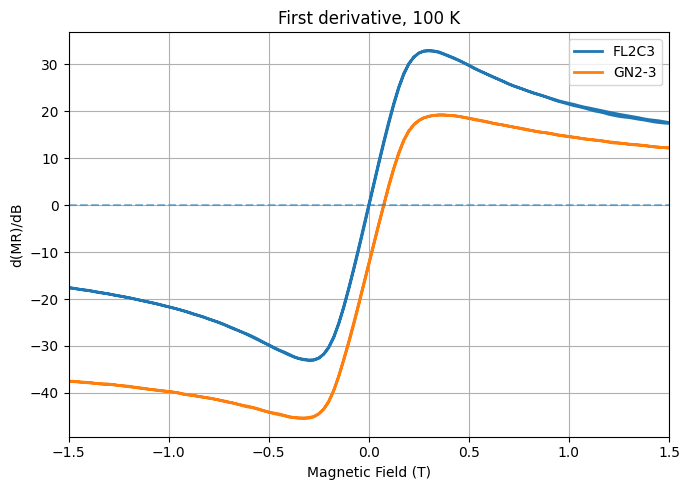

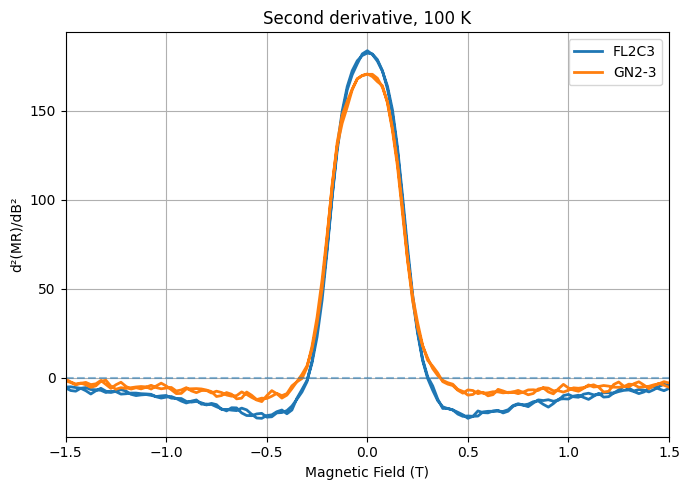


Processing Ch-3-FL2-C-3 and Ch-2-GN2-3 samples_MRat 200K_updated+-2Tesla.dat

FL2C3:
  H− = -0.313285 Oe, R0− = 2.77079388e-01
  H+ = 0.375069 Oe, R0+ = 2.73928546e-01
  R0_average = 2.75503967e-01

GN2-3:
  H− = -0.313285 Oe, R0− = 1.75541975e-01
  H+ = 0.375069 Oe, R0+ = 1.78919435e-01
  R0_average = 1.77230705e-01


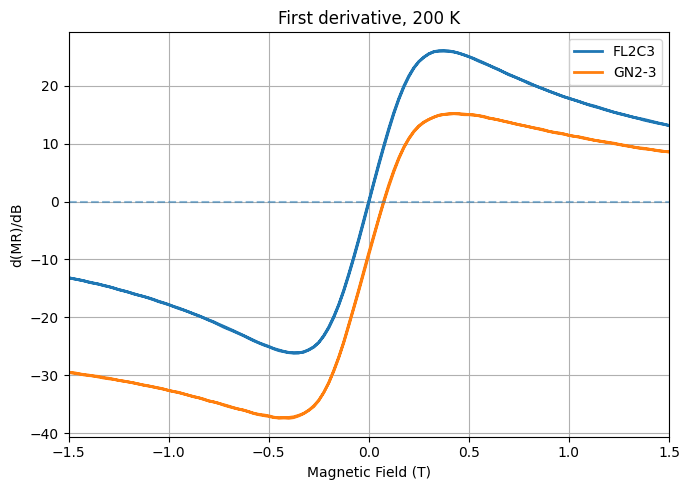

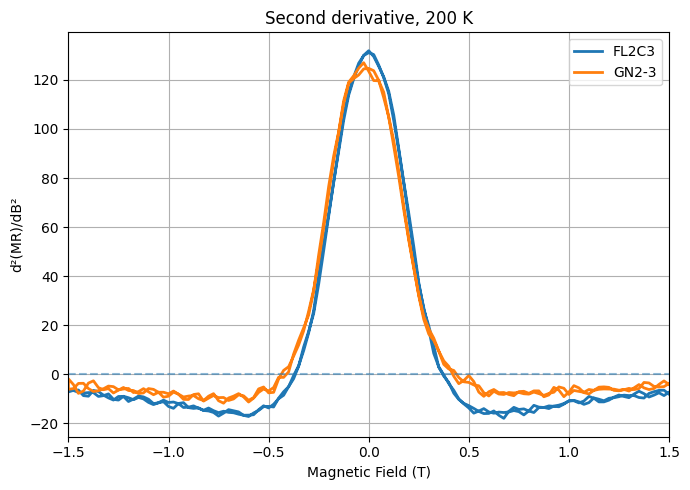


Processing Ch-3-FL2-C-3 and Ch-2-GN2-3 samples_MRat 20K_updated+-2Tesla.dat

FL2C3:
  H− = -0.277668 Oe, R0− = 5.53203657e-01
  H+ = 0.095221 Oe, R0+ = 5.55017664e-01
  R0_average = 5.54110661e-01

GN2-3:
  H− = -0.277668 Oe, R0− = 3.66586759e-01
  H+ = 0.095221 Oe, R0+ = 3.73627993e-01
  R0_average = 3.70107376e-01


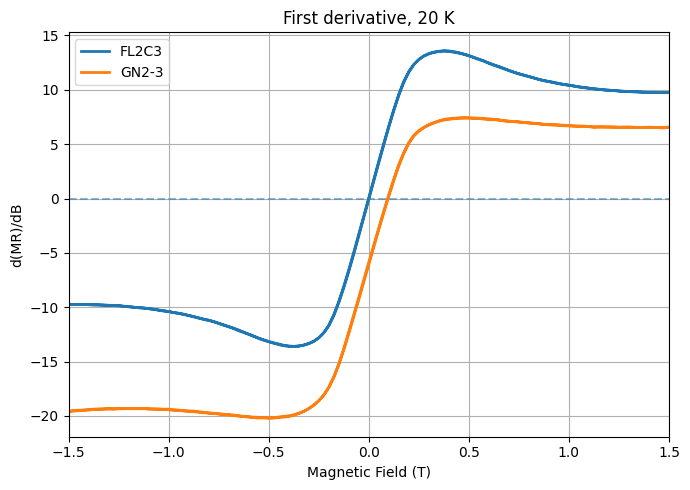

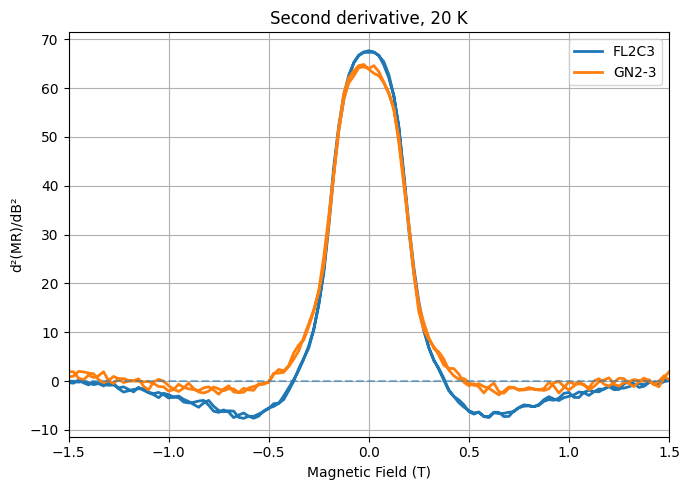


Processing Ch-3-FL2-C-3 and Ch-2-GN2-3 samples_MRat 250K_updated+-2Tesla.dat

FL2C3:
  H− = -249.938022 Oe, R0− = 9.50927326e-02
  H+ = 0.024714 Oe, R0+ = 8.55571406e-02
  R0_average = 9.03249366e-02

GN2-3:
  H− = -249.938022 Oe, R0− = 6.57103784e-02
  H+ = 0.024714 Oe, R0+ = 5.63061563e-02
  R0_average = 6.10082674e-02


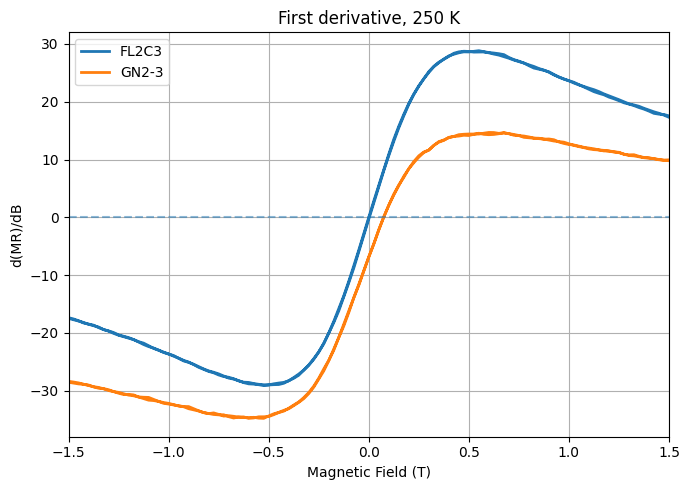

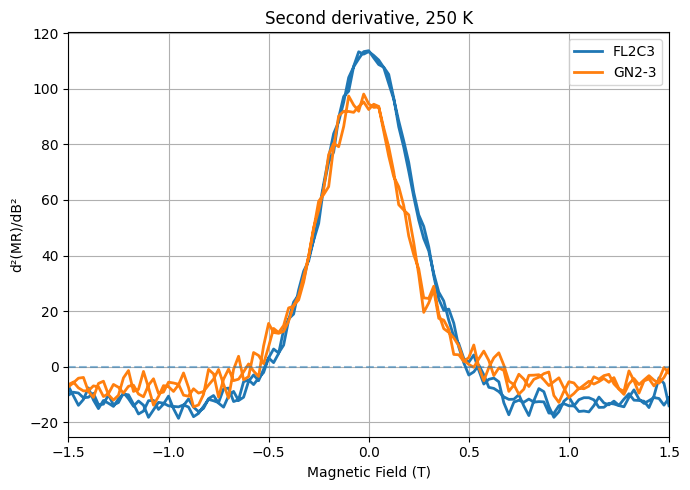


Processing Ch-3-FL2-C-3 and Ch-2-GN2-3 samples_MRat 300K_updated+-2Tesla.dat

FL2C3:
  H− = -0.073415 Oe, R0− = 2.93465498e-02
  H+ = 0.005815 Oe, R0+ = 2.51097594e-02
  R0_average = 2.72281546e-02

GN2-3:
  H− = -0.073415 Oe, R0− = 1.85220150e-02
  H+ = 0.005815 Oe, R0+ = 1.80566383e-02
  R0_average = 1.82893266e-02


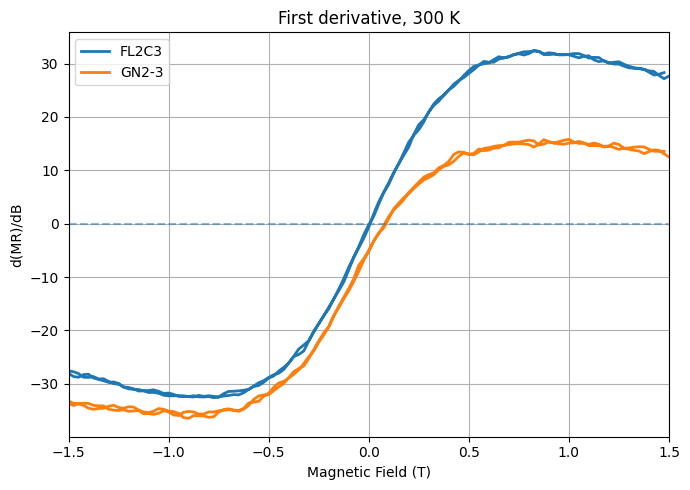

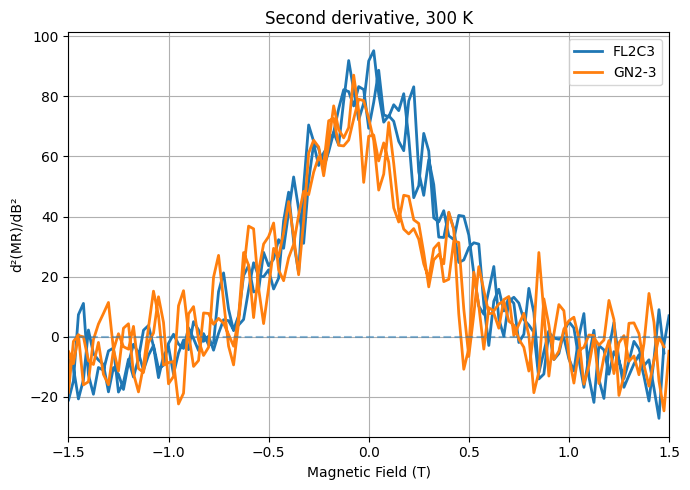


Processing Ch-3-FL2-C-3 and Ch-2-GN2-3 samples_MRat 50K_updated+-2Tesla.dat

FL2C3:
  H− = -0.188988 Oe, R0− = 3.10018067e-01
  H+ = 0.341633 Oe, R0+ = 3.12727064e-01
  R0_average = 3.11372566e-01

GN2-3:
  H− = -0.188988 Oe, R0− = 2.10223171e-01
  H+ = 0.341633 Oe, R0+ = 2.05210763e-01
  R0_average = 2.07716967e-01


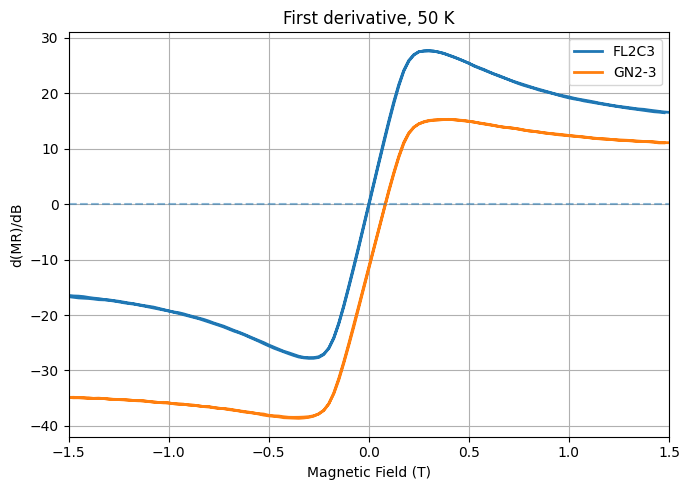

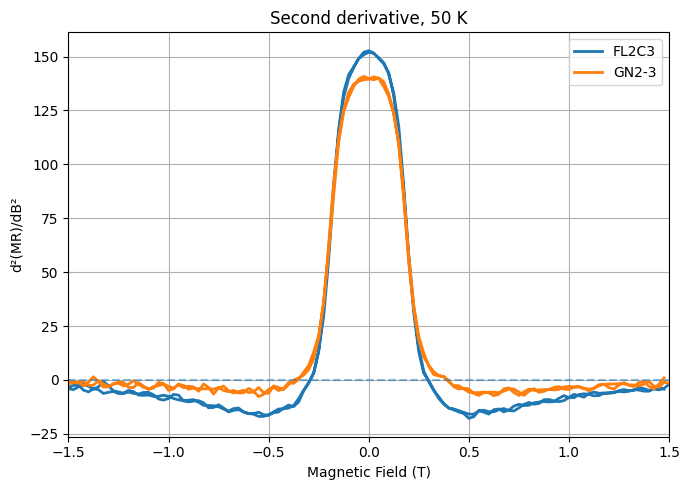


R0 SUMMARY
 Temperature_K                                                          Filename  FL2C3_H_minus_Oe  FL2C3_R0_minus  FL2C3_H_plus_Oe  FL2C3_R0_plus  FL2C3_R0_average  GN2-3_H_minus_Oe  GN2-3_R0_minus  GN2-3_H_plus_Oe  GN2-3_R0_plus  GN2-3_R0_average
            20  Ch-3-FL2-C-3 and Ch-2-GN2-3 samples_MRat 20K_updated+-2Tesla.dat         -0.277668        0.553204         0.095221       0.555018          0.554111         -0.277668        0.366587         0.095221       0.373628          0.370107
            50  Ch-3-FL2-C-3 and Ch-2-GN2-3 samples_MRat 50K_updated+-2Tesla.dat         -0.188988        0.310018         0.341633       0.312727          0.311373         -0.188988        0.210223         0.341633       0.205211          0.207717
           100 Ch-3-FL2-C-3 and Ch-2-GN2-3 samples_MRat 100K_updated+-2Tesla.dat         -0.236963        0.278643         0.590953       0.282450          0.280546         -0.236963        0.183204         0.590953       0.184183          0

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import zipfile, os, re
from google.colab import files

SMOOTH_WINDOW = 15   # derivatives need stronger smoothing

uploaded = files.upload()
zipname = list(uploaded.keys())[0]

input_dir = "data_files"
outdir = "MR_outputs"
os.makedirs(input_dir, exist_ok=True)
os.makedirs(outdir, exist_ok=True)

with zipfile.ZipFile(zipname, 'r') as z:
    z.extractall(input_dir)

def find_data_start(filepath):
    with open(filepath, 'r', errors='ignore') as f:
        lines = f.readlines()
    for i, line in enumerate(lines):
        if line.strip() == "[Data]":
            return i + 1
    raise ValueError(f"[Data] section not found in {filepath}")

def extract_temperature(filename):
    match = re.search(r'MRat\s*(\d+)K', filename)
    return int(match.group(1)) if match else None

def get_R0_Hminus_Hplus(df, sample_col):
    neg = df[df['Field_Oe'] < 0].copy()
    pos = df[df['Field_Oe'] > 0].copy()

    idx_neg = neg['Field_Oe'].abs().idxmin()
    idx_pos = pos['Field_Oe'].abs().idxmin()

    H_neg = df.loc[idx_neg, 'Field_Oe']
    R_neg = df.loc[idx_neg, sample_col]
    H_pos = df.loc[idx_pos, 'Field_Oe']
    R_pos = df.loc[idx_pos, sample_col]

    R_avg = 0.5 * (R_neg + R_pos)

    return H_neg, R_neg, H_pos, R_pos, R_avg

def add_MR_and_derivatives(df, sample_col, label):
    H_neg, R_neg, H_pos, R_pos, R_avg = get_R0_Hminus_Hplus(df, sample_col)

    df[f'MR_{label}_plus'] = (df[sample_col] - R_pos) / R_pos
    df[f'MR_{label}_minus'] = (df[sample_col] - R_neg) / R_neg
    df[f'MR_{label}_average'] = (df[sample_col] - R_avg) / R_avg

    df[f'MR_{label}_average_smooth'] = (
        df[f'MR_{label}_average']
        .rolling(window=SMOOTH_WINDOW, center=True, min_periods=1)
        .mean()
    )

    df[f'dMRdB_{label}'] = np.gradient(
        df[f'MR_{label}_average_smooth'],
        df['Field_T']
    )

    df[f'd2MRdB2_{label}'] = np.gradient(
        df[f'dMRdB_{label}'],
        df['Field_T']
    )

    return {
        'H_minus_Oe': H_neg,
        'R0_minus': R_neg,
        'H_plus_Oe': H_pos,
        'R0_plus': R_pos,
        'R0_average': R_avg
    }

def plot_derivatives_pm15(df, T, base):
    plot_df = df[(df['Field_T'] >= -1.5) & (df['Field_T'] <= 1.5)].copy()

    plt.figure(figsize=(7,5))
    plt.plot(plot_df['Field_T'], plot_df['dMRdB_FL2C3'], linewidth=2, label='FL2C3')
    plt.plot(plot_df['Field_T'], plot_df['dMRdB_GN2-3'], linewidth=2, label='GN2-3')
    plt.axhline(0, linestyle='--', alpha=0.5)
    plt.xlabel('Magnetic Field (T)')
    plt.ylabel('d(MR)/dB')
    plt.title(f'First derivative, {T} K')
    plt.xlim(-1.5, 1.5)
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.savefig(os.path.join(outdir, base + "_first_derivative_pm1p5T.png"), dpi=300)
    plt.show()

    plt.figure(figsize=(7,5))
    plt.plot(plot_df['Field_T'], plot_df['d2MRdB2_FL2C3'], linewidth=2, label='FL2C3')
    plt.plot(plot_df['Field_T'], plot_df['d2MRdB2_GN2-3'], linewidth=2, label='GN2-3')
    plt.axhline(0, linestyle='--', alpha=0.5)
    plt.xlabel('Magnetic Field (T)')
    plt.ylabel('d²(MR)/dB²')
    plt.title(f'Second derivative, {T} K')
    plt.xlim(-1.5, 1.5)
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.savefig(os.path.join(outdir, base + "_second_derivative_pm1p5T.png"), dpi=300)
    plt.show()

r0_rows = []

for root, dirs, filenames in os.walk(input_dir):
    for fname in sorted(filenames):

        if "MRat" not in fname:
            continue

        filepath = os.path.join(root, fname)
        T = extract_temperature(fname)
        base = os.path.splitext(fname)[0]

        print("\n" + "="*80)
        print(f"Processing {fname}")
        print("="*80)

        data_start = find_data_start(filepath)
        df = pd.read_csv(filepath, skiprows=data_start)

        df = df.rename(columns={
            'Magnetic Field (Oe)': 'Field_Oe',
            'Bridge 3 Resistivity (Ohm)': 'FL2C3',
            'Bridge 2 Resistivity (Ohm)': 'GN2-3'
        })

        df = df[['Field_Oe', 'FL2C3', 'GN2-3']].dropna()
        df['Field_T'] = df['Field_Oe'] * 1e-4

        fl2c3 = add_MR_and_derivatives(df, 'FL2C3', 'FL2C3')
        gn23 = add_MR_and_derivatives(df, 'GN2-3', 'GN2-3')

        print("\nFL2C3:")
        print(f"  H− = {fl2c3['H_minus_Oe']:.6f} Oe, R0− = {fl2c3['R0_minus']:.8e}")
        print(f"  H+ = {fl2c3['H_plus_Oe']:.6f} Oe, R0+ = {fl2c3['R0_plus']:.8e}")
        print(f"  R0_average = {fl2c3['R0_average']:.8e}")

        print("\nGN2-3:")
        print(f"  H− = {gn23['H_minus_Oe']:.6f} Oe, R0− = {gn23['R0_minus']:.8e}")
        print(f"  H+ = {gn23['H_plus_Oe']:.6f} Oe, R0+ = {gn23['R0_plus']:.8e}")
        print(f"  R0_average = {gn23['R0_average']:.8e}")

        r0_rows.append({
            'Temperature_K': T,
            'Filename': fname,
            'FL2C3_H_minus_Oe': fl2c3['H_minus_Oe'],
            'FL2C3_R0_minus': fl2c3['R0_minus'],
            'FL2C3_H_plus_Oe': fl2c3['H_plus_Oe'],
            'FL2C3_R0_plus': fl2c3['R0_plus'],
            'FL2C3_R0_average': fl2c3['R0_average'],
            'GN2-3_H_minus_Oe': gn23['H_minus_Oe'],
            'GN2-3_R0_minus': gn23['R0_minus'],
            'GN2-3_H_plus_Oe': gn23['H_plus_Oe'],
            'GN2-3_R0_plus': gn23['R0_plus'],
            'GN2-3_R0_average': gn23['R0_average']
        })

        plot_derivatives_pm15(df, T, base)

        df.to_csv(os.path.join(outdir, base + "_MR_derivatives.csv"), index=False)

r0_table = pd.DataFrame(r0_rows).sort_values('Temperature_K')
r0_table.to_csv(os.path.join(outdir, "R0_summary.csv"), index=False)

print("\nR0 SUMMARY")
print(r0_table.to_string(index=False))

zip_out = "MR_derivatives_pm1p5T.zip"

with zipfile.ZipFile(zip_out, 'w') as z:
    for root, dirs, filenames in os.walk(outdir):
        for f in filenames:
            fullpath = os.path.join(root, f)
            z.write(fullpath, arcname=os.path.relpath(fullpath, outdir))

files.download(zip_out)

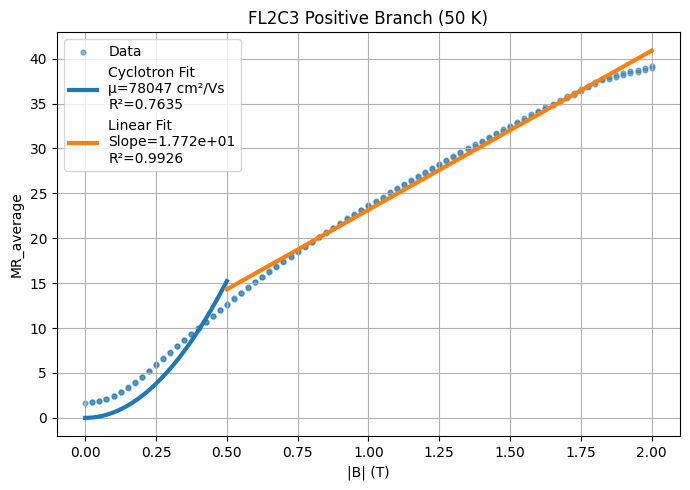

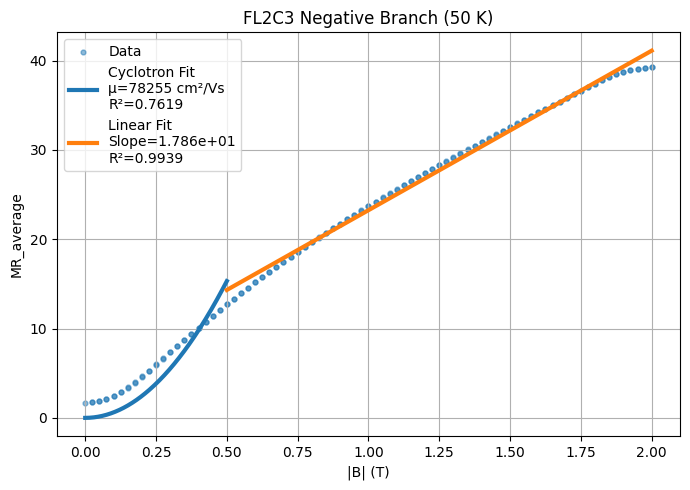

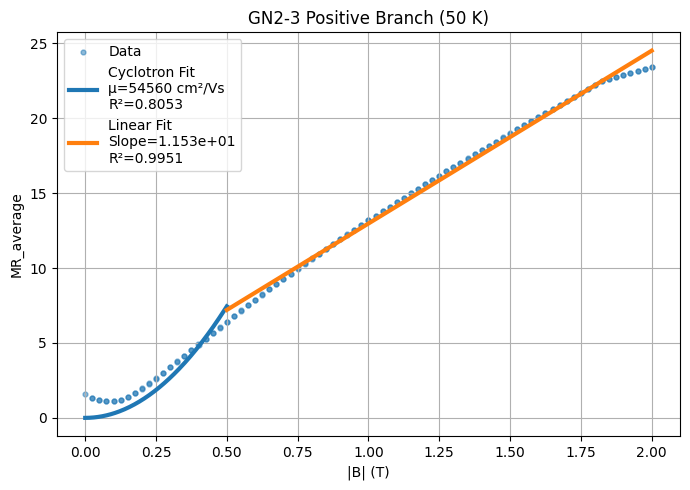

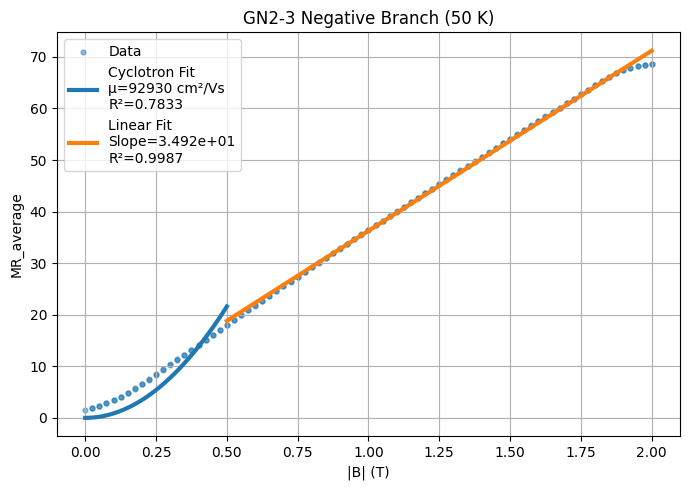



FIT SUMMARY


,Temperature_K,Sample,Branch,Mobility_cm2_Vs,Quadratic_a,Quadratic_R2,Linear_slope,Linear_intercept,Linear_R2
0,50,FL2C3,Positive,78047.302517,60.913814,0.763539,17.718603,5.454837,0.992617
1,50,FL2C3,Negative,78254.513350,61.237689,0.761940,17.855953,5.390281,0.993909
2,50,GN2-3,Positive,54560.476690,29.768456,0.805289,11.533650,1.436980,0.995119
3,50,GN2-3,Negative,92929.504960,86.358929,0.783289,34.923432,1.349617,0.998703



Saved:
MR_cyclotron_linear_fit_summary.csv


In [3]:
from scipy.optimize import curve_fit

# ============================================================
# FIT SETTINGS
# ============================================================

QUAD_MAX = 0.5
LINEAR_MIN = 0.5
LINEAR_MAX = 2.0

# ============================================================
# HELPER FUNCTIONS
# ============================================================

def quadratic_model(B, a):
    return a * B**2

def linear_model(B, m, c):
    return m * B + c

def calculate_r2(y, yfit):

    ss_res = np.sum((y - yfit)**2)
    ss_tot = np.sum((y - np.mean(y))**2)

    if ss_tot == 0:
        return np.nan

    return 1 - ss_res / ss_tot

# ============================================================
# STORAGE
# ============================================================

fit_summary = []

# ============================================================
# ANALYSIS FUNCTION
# ============================================================

def analyze_branch(B, MR, sample_name, branch_name):

    # --------------------------------------------------------
    # QUADRATIC FIT
    # --------------------------------------------------------

    quad_mask = (
        (B >= 0.0) &
        (B <= QUAD_MAX)
    )

    B_quad = B[quad_mask]
    MR_quad = MR[quad_mask]

    popt_quad, _ = curve_fit(
        quadratic_model,
        B_quad,
        MR_quad
    )

    a = popt_quad[0]

    MR_quad_fit = quadratic_model(
        B_quad,
        a
    )

    r2_quad = calculate_r2(
        MR_quad,
        MR_quad_fit
    )

    mu_m2_vs = np.sqrt(abs(a))
    mu_cm2_vs = mu_m2_vs * 1e4

    # --------------------------------------------------------
    # LINEAR FIT
    # --------------------------------------------------------

    lin_mask = (
        (B >= LINEAR_MIN) &
        (B <= LINEAR_MAX)
    )

    B_lin = B[lin_mask]
    MR_lin = MR[lin_mask]

    popt_lin, _ = curve_fit(
        linear_model,
        B_lin,
        MR_lin
    )

    m, c = popt_lin

    MR_lin_fit = linear_model(
        B_lin,
        m,
        c
    )

    r2_lin = calculate_r2(
        MR_lin,
        MR_lin_fit
    )

    # --------------------------------------------------------
    # PLOT
    # --------------------------------------------------------

    plt.figure(figsize=(7,5))

    plt.scatter(
        B,
        MR,
        s=12,
        alpha=0.5,
        label='Data'
    )

    B_quad_theory = np.linspace(
        0,
        QUAD_MAX,
        200
    )

    plt.plot(
        B_quad_theory,
        quadratic_model(B_quad_theory, a),
        linewidth=3,
        label=(
            f'Cyclotron Fit\n'
            f'μ={mu_cm2_vs:.0f} cm²/Vs\n'
            f'R²={r2_quad:.4f}'
        )
    )

    B_lin_theory = np.linspace(
        LINEAR_MIN,
        LINEAR_MAX,
        200
    )

    plt.plot(
        B_lin_theory,
        linear_model(B_lin_theory, m, c),
        linewidth=3,
        label=(
            f'Linear Fit\n'
            f'Slope={m:.3e}\n'
            f'R²={r2_lin:.4f}'
        )
    )

    plt.xlabel('|B| (T)')
    plt.ylabel('MR_average')
    plt.title(
        f'{sample_name} {branch_name} Branch ({T} K)'
    )

    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()

    # --------------------------------------------------------
    # SAVE RESULTS
    # --------------------------------------------------------

    fit_summary.append({

        'Temperature_K': T,

        'Sample': sample_name,
        'Branch': branch_name,

        'Mobility_cm2_Vs': mu_cm2_vs,

        'Quadratic_a': a,
        'Quadratic_R2': r2_quad,

        'Linear_slope': m,
        'Linear_intercept': c,
        'Linear_R2': r2_lin
    })

# ============================================================
# FL2C3
# ============================================================

MR = df['MR_FL2C3_average_smooth']

# Positive branch

mask = df['Field_T'] > 0

B_pos = df.loc[mask, 'Field_T'].values
MR_pos = MR[mask].values

analyze_branch(
    B_pos,
    MR_pos,
    'FL2C3',
    'Positive'
)

# Negative branch

mask = df['Field_T'] < 0

B_neg = np.abs(
    df.loc[mask, 'Field_T'].values
)

MR_neg = MR[mask].values

analyze_branch(
    B_neg,
    MR_neg,
    'FL2C3',
    'Negative'
)

# ============================================================
# GN2-3
# ============================================================

MR = df['MR_GN2-3_average_smooth']

# Positive branch

mask = df['Field_T'] > 0

B_pos = df.loc[mask, 'Field_T'].values
MR_pos = MR[mask].values

analyze_branch(
    B_pos,
    MR_pos,
    'GN2-3',
    'Positive'
)

# Negative branch

mask = df['Field_T'] < 0

B_neg = np.abs(
    df.loc[mask, 'Field_T'].values
)

MR_neg = MR[mask].values

analyze_branch(
    B_neg,
    MR_neg,
    'GN2-3',
    'Negative'
)

# ============================================================
# RESULTS TABLE
# ============================================================

fit_summary_df = pd.DataFrame(
    fit_summary
)

print("\n")
print("="*80)
print("FIT SUMMARY")
print("="*80)

display(fit_summary_df)

fit_summary_df.to_csv(
    "MR_cyclotron_linear_fit_summary.csv",
    index=False
)

print("\nSaved:")
print("MR_cyclotron_linear_fit_summary.csv")


Analyzing Ch-3-FL2-C-3 and Ch-2-GN2-3 samples_MRat 100K_updated+-2Tesla_MR_with_derivatives.csv


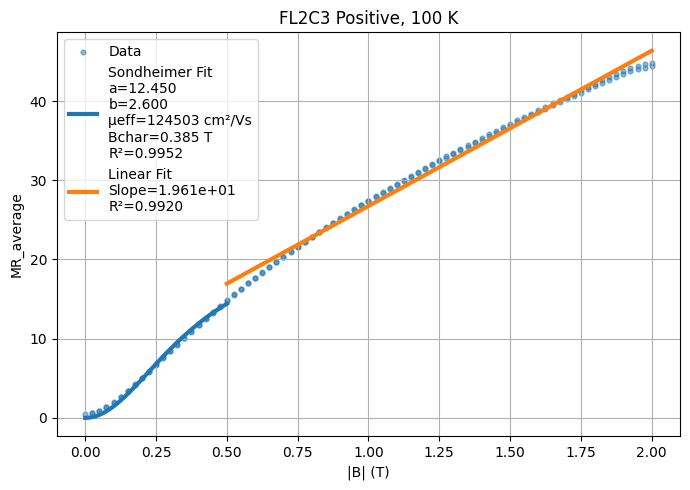

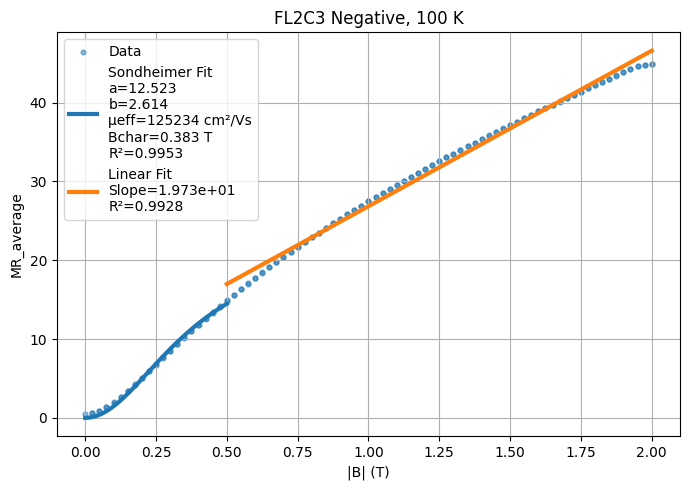

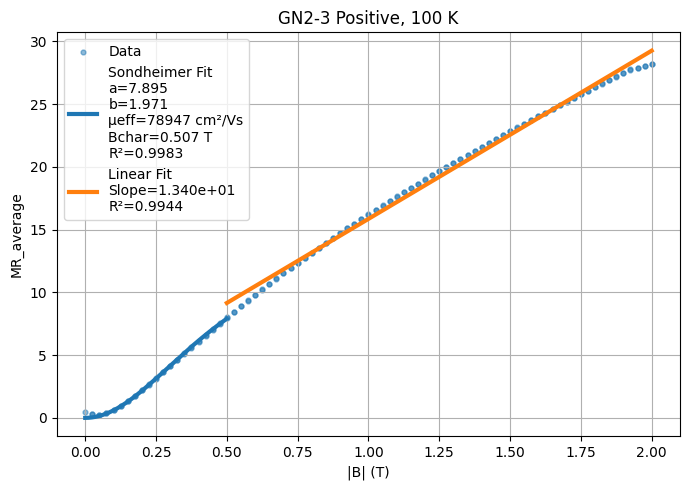

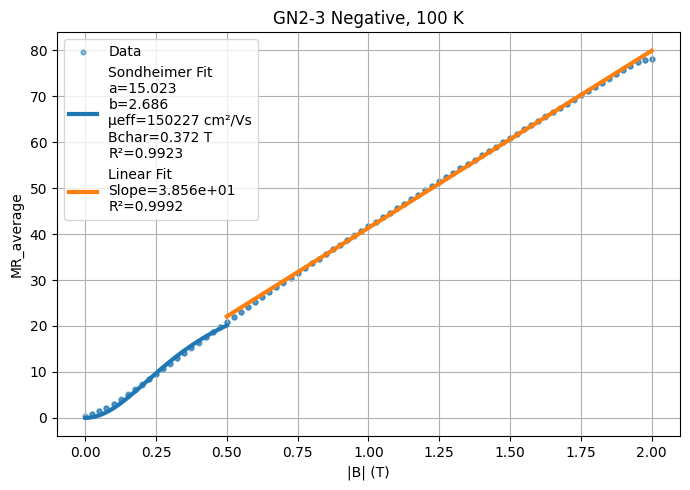


Analyzing Ch-3-FL2-C-3 and Ch-2-GN2-3 samples_MRat 200K_updated+-2Tesla_MR_with_derivatives.csv


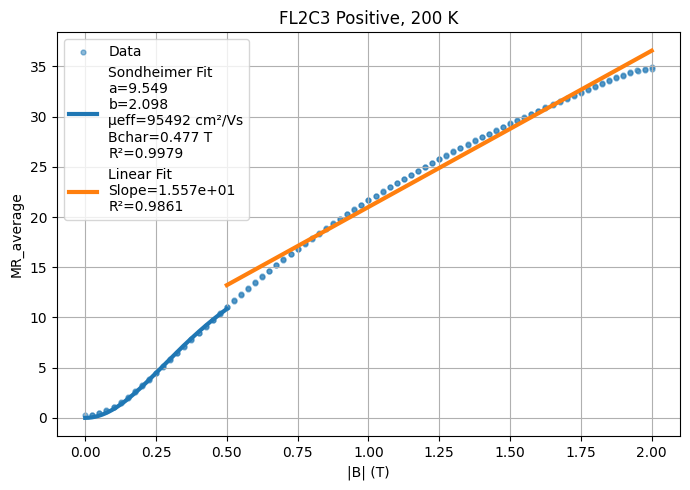

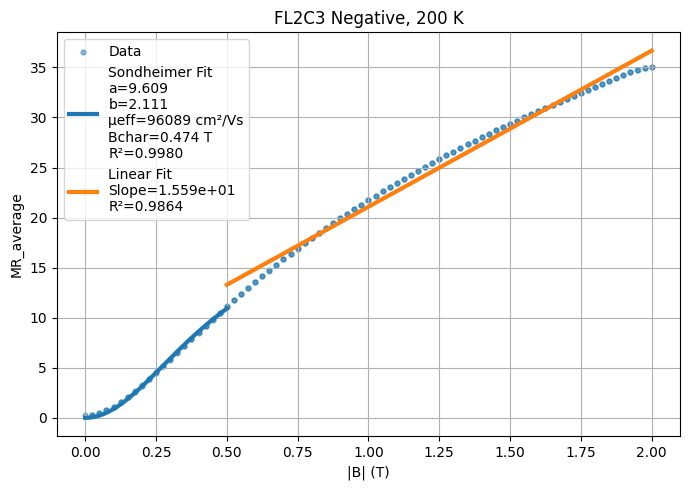

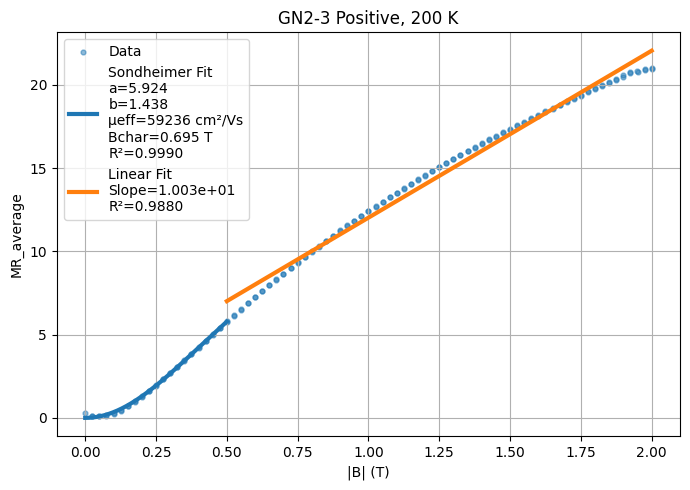

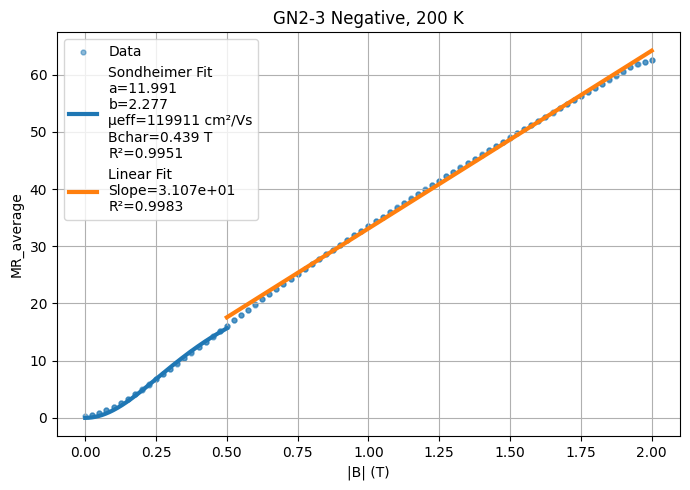


Analyzing Ch-3-FL2-C-3 and Ch-2-GN2-3 samples_MRat 20K_updated+-2Tesla_MR_with_derivatives.csv


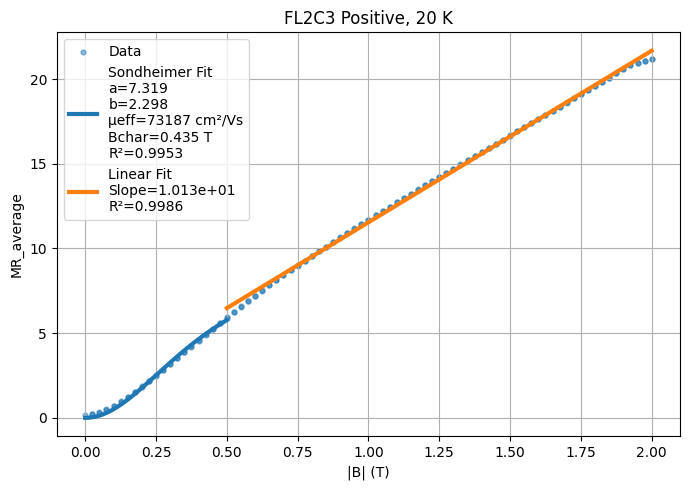

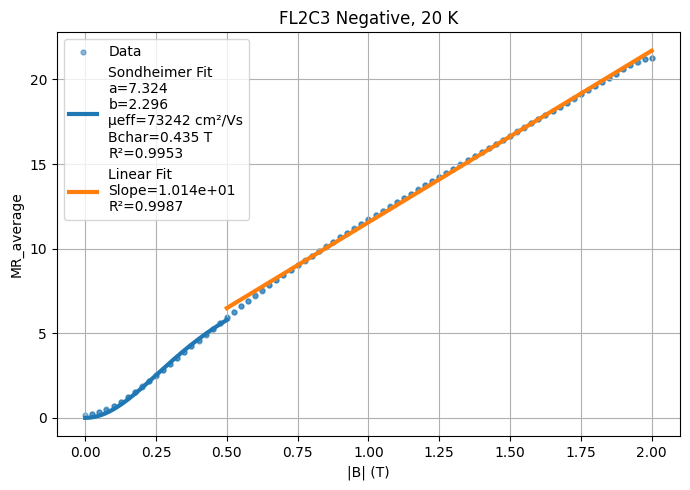

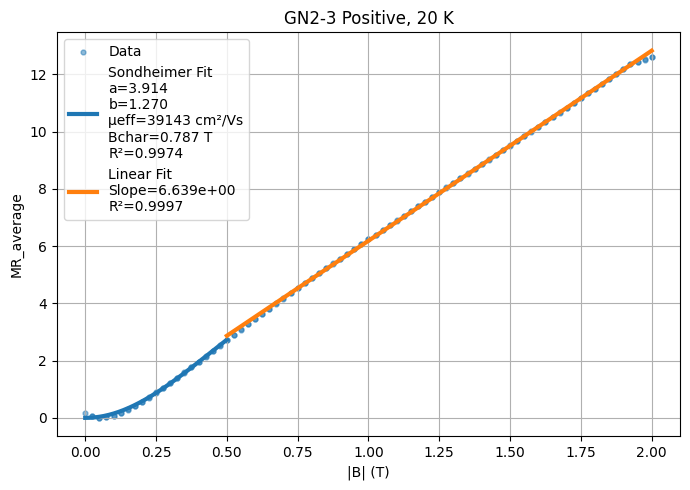

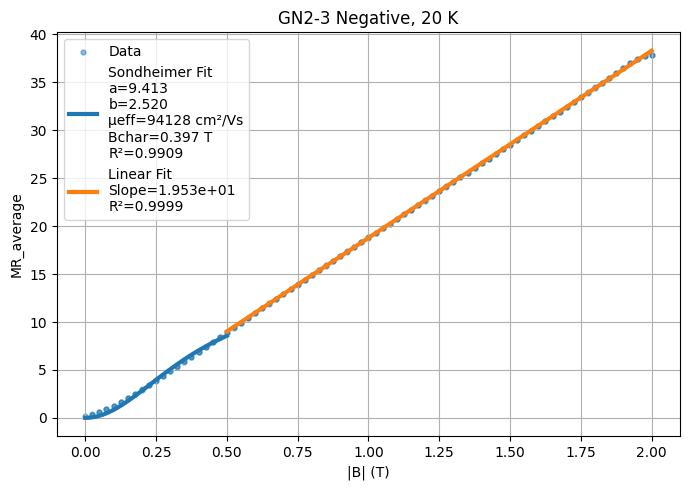


Analyzing Ch-3-FL2-C-3 and Ch-2-GN2-3 samples_MRat 250K_updated+-2Tesla_MR_with_derivatives.csv


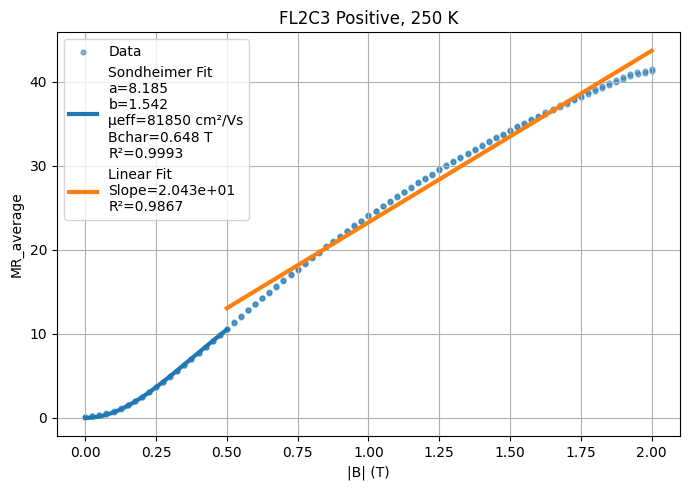

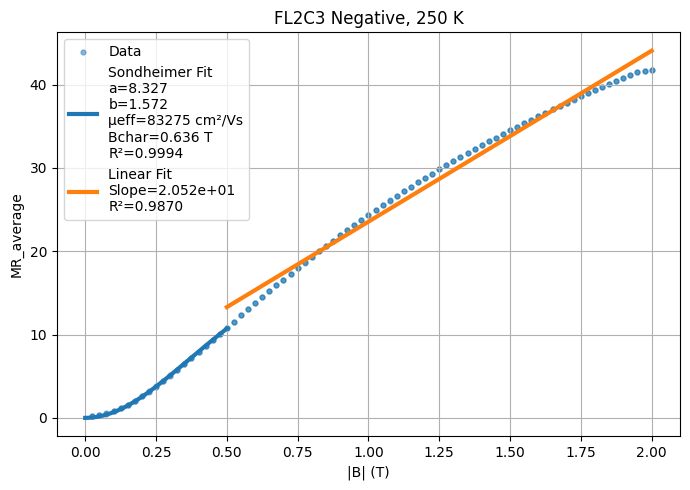

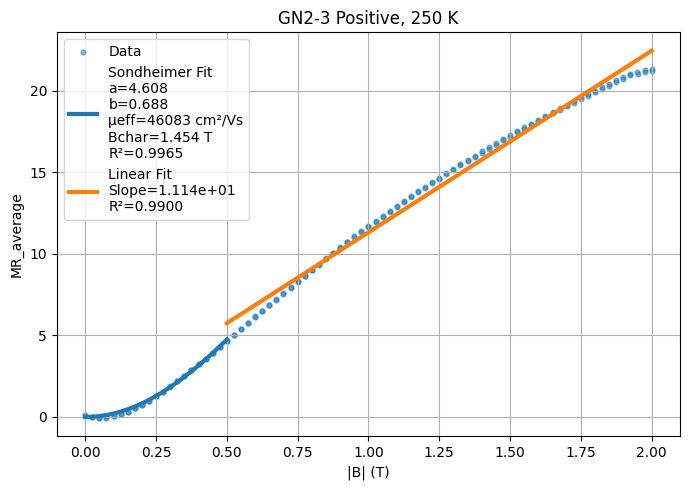

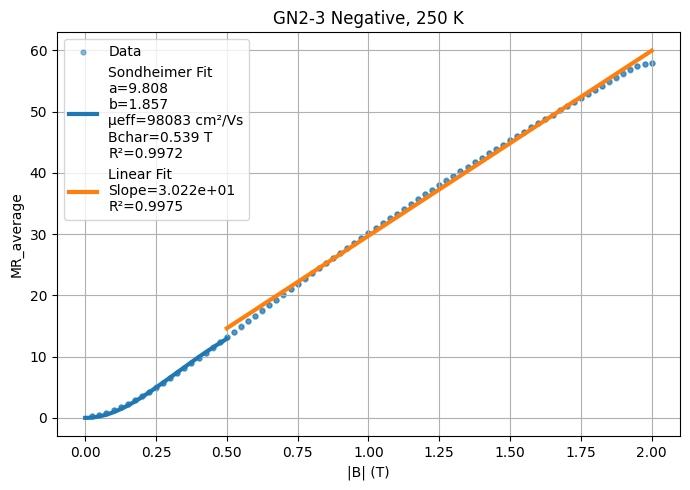


Analyzing Ch-3-FL2-C-3 and Ch-2-GN2-3 samples_MRat 300K_updated+-2Tesla_MR_with_derivatives.csv


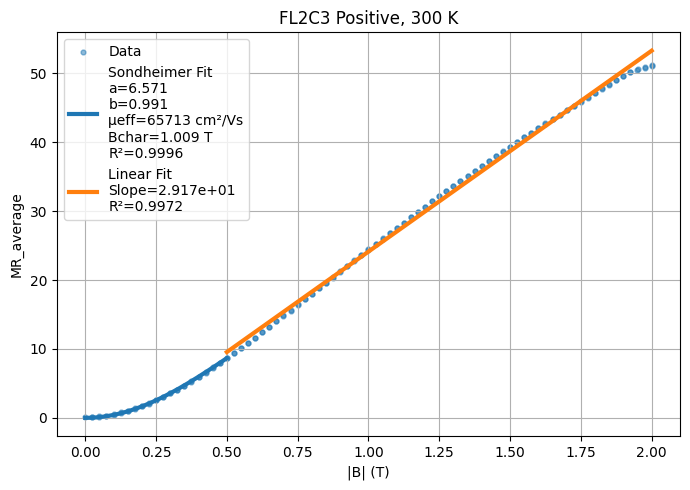

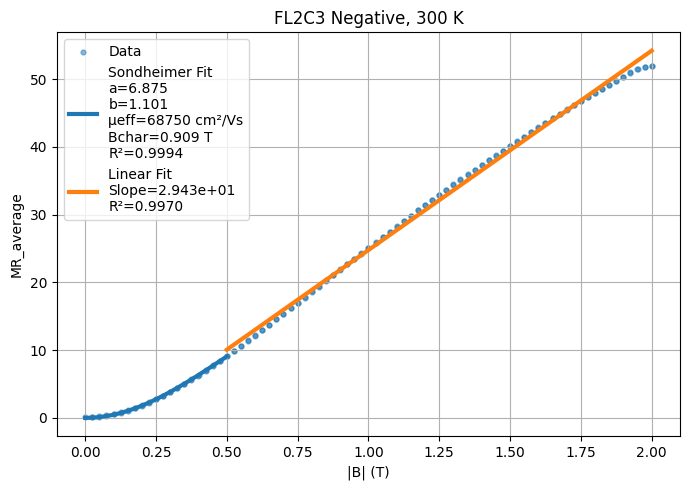

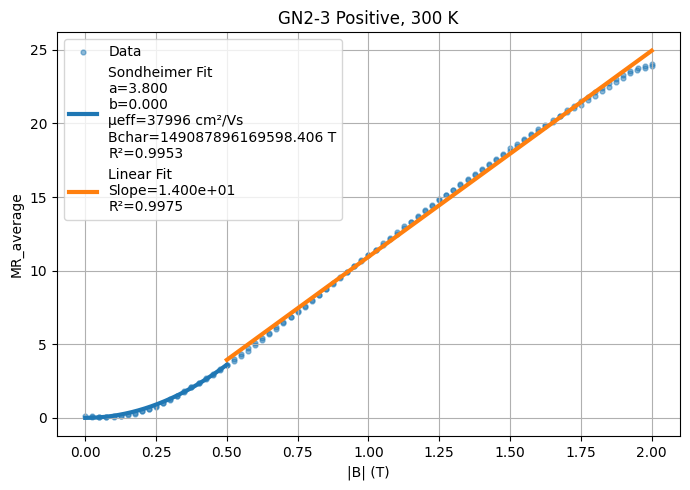

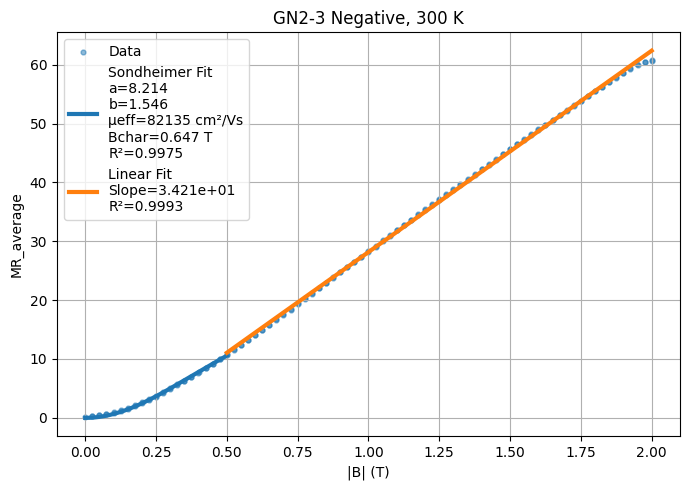


Analyzing Ch-3-FL2-C-3 and Ch-2-GN2-3 samples_MRat 50K_updated+-2Tesla_MR_with_derivatives.csv


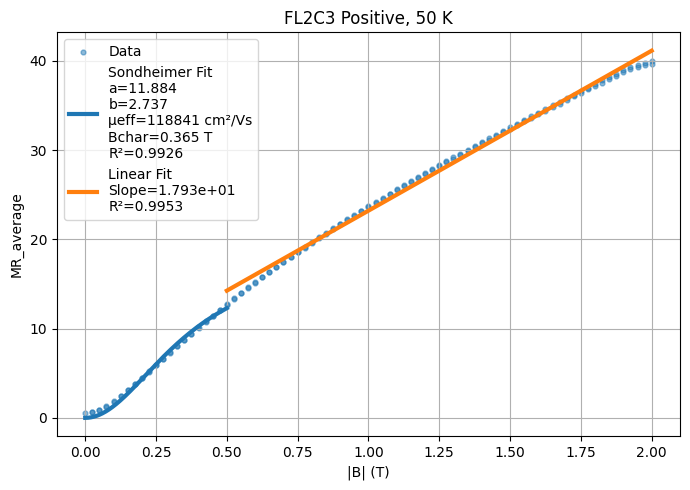

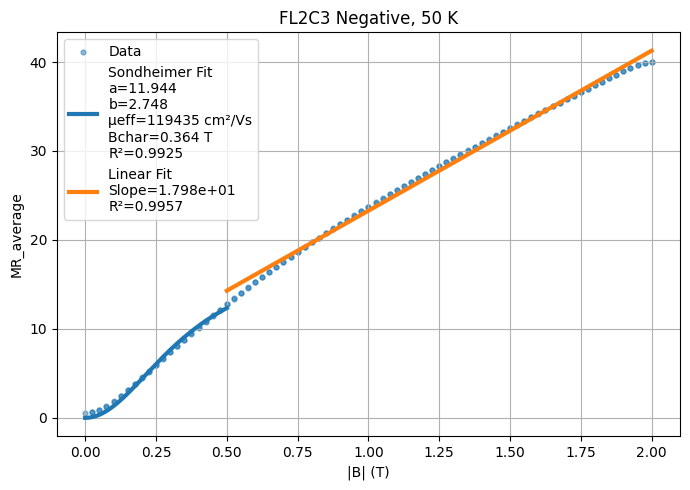

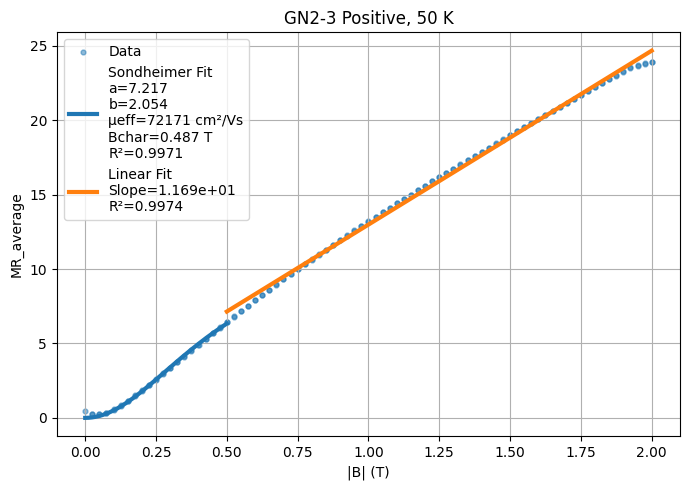

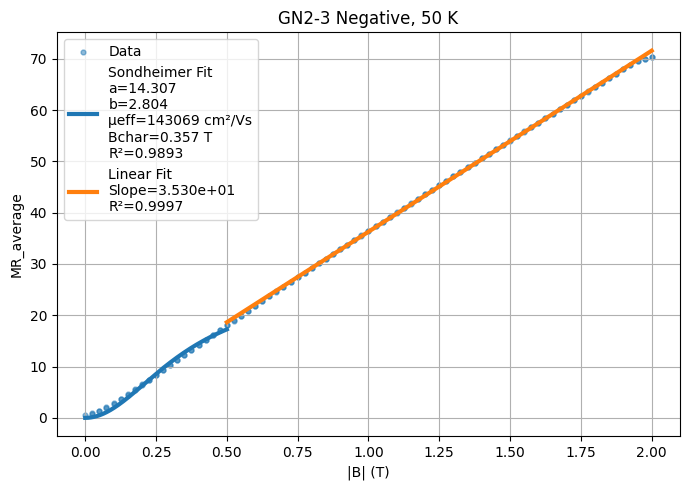

,Temperature_K,Sample,Branch,a_parameter,b_parameter,Mobility_like_cm2_Vs,Characteristic_Field_T,Sondheimer_R2,Linear_slope,Linear_intercept,Linear_R2
9,20,FL2C3,Negative,7.324160,2.296239e+00,73241.599559,4.354947e-01,0.995339,10.140160,1.418654,0.998702
8,20,FL2C3,Positive,7.318712,2.297816e+00,73187.116023,4.351958e-01,0.995345,10.132109,1.411690,0.998595
11,20,GN2-3,Negative,9.412794,2.520017e+00,94127.944500,3.968227e-01,0.990854,19.526999,-0.749775,0.999919
10,20,GN2-3,Positive,3.914302,1.270195e+00,39143.016360,7.872809e-01,0.997393,6.639423,-0.452541,0.999665
21,50,FL2C3,Negative,11.943536,2.748144e+00,119435.361987,3.638819e-01,0.992480,17.984146,5.305530,0.995731
20,50,FL2C3,Positive,11.884067,2.736678e+00,118840.672108,3.654065e-01,0.992570,17.928339,5.290726,0.995271
23,50,GN2-3,Negative,14.306941,2.804307e+00,143069.410411,3.565943e-01,0.989331,35.296868,0.994492,0.999697
22,50,GN2-3,Positive,7.217108,2.053877e+00,72171.084991,4.868842e-01,0.997058,11.688597,1.302799,0.997377
1,100,FL2C3,Negative,12.523354,2.613656e+00,125233.540694,3.826059e-01,0.995270,19.734263,7.111536,0.992800
0,100,FL2C3,Positive,12.450270,2.599563e+00,124502.697673,3.846800e-01,0.995243,19.609437,7.146327,0.992049


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [7]:
from scipy.optimize import curve_fit
import glob

# ============================================================
# FIT SETTINGS
# ============================================================

SONDHEIMER_MAX = 0.5
LINEAR_MIN = 0.5
LINEAR_MAX = 2.0

fit_summary = []

# ============================================================
# MODELS
# ============================================================

def sondheimer_ab_model(B, a, b):
    return (a * B)**2 / (1 + (b * B)**2)

def linear_model(B, m, c):
    return m * B + c

def calculate_r2(y, yfit):
    ss_res = np.sum((y - yfit)**2)
    ss_tot = np.sum((y - np.mean(y))**2)
    return np.nan if ss_tot == 0 else 1 - ss_res / ss_tot

def extract_temperature(filename):
    match = re.search(r'MRat\s*(\d+)K', filename)
    return int(match.group(1)) if match else None

# ============================================================
# FIT FUNCTION
# ============================================================

def analyze_branch_ab(B, MR, sample_name, branch_name, T, base):

    B = np.asarray(B)
    MR = np.asarray(MR)

    valid = np.isfinite(B) & np.isfinite(MR)
    B = B[valid]
    MR = MR[valid]

    # Sondheimer low-field fit
    low_mask = (B >= 0) & (B <= SONDHEIMER_MAX)
    B_low = B[low_mask]
    MR_low = MR[low_mask]

    popt_ab, _ = curve_fit(
        sondheimer_ab_model,
        B_low,
        MR_low,
        p0=[1.0, 1.0],
        bounds=([0, 0], [np.inf, np.inf]),
        maxfev=20000
    )

    a_fit, b_fit = popt_ab
    MR_ab_fit = sondheimer_ab_model(B_low, a_fit, b_fit)
    r2_ab = calculate_r2(MR_low, MR_ab_fit)

    mu_eff_cm2_vs = a_fit * 1e4
    characteristic_field_T = 1 / b_fit if b_fit > 0 else np.nan

    # Linear high-field fit
    lin_mask = (B >= LINEAR_MIN) & (B <= LINEAR_MAX)
    B_lin = B[lin_mask]
    MR_lin = MR[lin_mask]

    popt_lin, _ = curve_fit(linear_model, B_lin, MR_lin)
    m_fit, c_fit = popt_lin

    MR_lin_fit = linear_model(B_lin, m_fit, c_fit)
    r2_lin = calculate_r2(MR_lin, MR_lin_fit)

    # Plot
    plt.figure(figsize=(7,5))

    plt.scatter(B, MR, s=12, alpha=0.5, label='Data')

    B_ab_theory = np.linspace(0, SONDHEIMER_MAX, 300)
    plt.plot(
        B_ab_theory,
        sondheimer_ab_model(B_ab_theory, a_fit, b_fit),
        linewidth=3,
        label=(
            f'Sondheimer Fit\n'
            f'a={a_fit:.3f}\n'
            f'b={b_fit:.3f}\n'
            f'μeff={mu_eff_cm2_vs:.0f} cm²/Vs\n'
            f'Bchar={characteristic_field_T:.3f} T\n'
            f'R²={r2_ab:.4f}'
        )
    )

    B_lin_theory = np.linspace(LINEAR_MIN, LINEAR_MAX, 300)
    plt.plot(
        B_lin_theory,
        linear_model(B_lin_theory, m_fit, c_fit),
        linewidth=3,
        label=(
            f'Linear Fit\n'
            f'Slope={m_fit:.3e}\n'
            f'R²={r2_lin:.4f}'
        )
    )

    plt.xlabel('|B| (T)')
    plt.ylabel('MR_average')
    plt.title(f'{sample_name} {branch_name}, {T} K')
    plt.grid(True)
    plt.legend()
    plt.tight_layout()

    plot_name = f'{base}_{sample_name}_{branch_name}_sondheimer_linear_fit.png'
    plt.savefig(os.path.join(outdir, plot_name), dpi=300)
    plt.show()

    fit_summary.append({
        'Temperature_K': T,
        'Sample': sample_name,
        'Branch': branch_name,
        'a_parameter': a_fit,
        'b_parameter': b_fit,
        'Mobility_like_cm2_Vs': mu_eff_cm2_vs,
        'Characteristic_Field_T': characteristic_field_T,
        'Sondheimer_R2': r2_ab,
        'Linear_slope': m_fit,
        'Linear_intercept': c_fit,
        'Linear_R2': r2_lin
    })

# ============================================================
# LOOP OVER ALL PROCESSED TEMPERATURE FILES
# ============================================================

processed_files = glob.glob(os.path.join(outdir, "*_MR_with_derivatives.csv"))

if len(processed_files) == 0:
    processed_files = glob.glob(os.path.join(outdir, "*_MR_derivatives.csv"))

for file in sorted(processed_files):

    fname = os.path.basename(file)
    base = os.path.splitext(fname)[0]
    T = extract_temperature(fname)

    print("\n" + "="*90)
    print(f"Analyzing {fname}")
    print("="*90)

    df = pd.read_csv(file)

    for sample in ['FL2C3', 'GN2-3']:

        MR = df[f'MR_{sample}_average_smooth']

        # Positive branch
        mask_pos = df['Field_T'] > 0
        B_pos = df.loc[mask_pos, 'Field_T'].values
        MR_pos = MR[mask_pos].values

        analyze_branch_ab(
            B_pos,
            MR_pos,
            sample,
            'Positive',
            T,
            base
        )

        # Negative branch
        mask_neg = df['Field_T'] < 0
        B_neg = np.abs(df.loc[mask_neg, 'Field_T'].values)
        MR_neg = MR[mask_neg].values

        analyze_branch_ab(
            B_neg,
            MR_neg,
            sample,
            'Negative',
            T,
            base
        )

# ============================================================
# EXPORT SUMMARY
# ============================================================

fit_summary_df = pd.DataFrame(fit_summary)
fit_summary_df = fit_summary_df.sort_values(['Temperature_K', 'Sample', 'Branch'])

display(fit_summary_df)

fit_summary_df.to_csv(
    os.path.join(outdir, "MR_sondheimer_ab_linear_fit_summary_ALL_T.csv"),
    index=False
)

zip_out = "MR_sondheimer_linear_fits_ALL_T.zip"

with zipfile.ZipFile(zip_out, 'w') as z:
    for root, dirs, filenames in os.walk(outdir):
        for f in filenames:
            fullpath = os.path.join(root, f)
            z.write(fullpath, arcname=os.path.relpath(fullpath, outdir))

files.download(zip_out)


Analyzing Ch-3-FL2-C-3 and Ch-2-GN2-3 samples_MRat 100K_updated+-2Tesla_MR_with_derivatives.csv


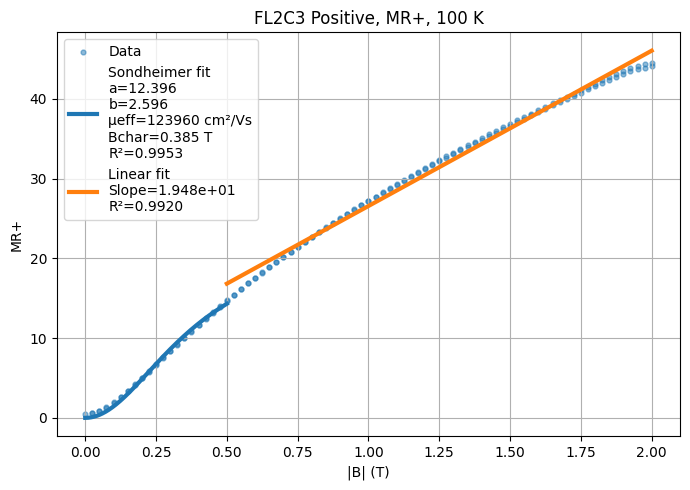

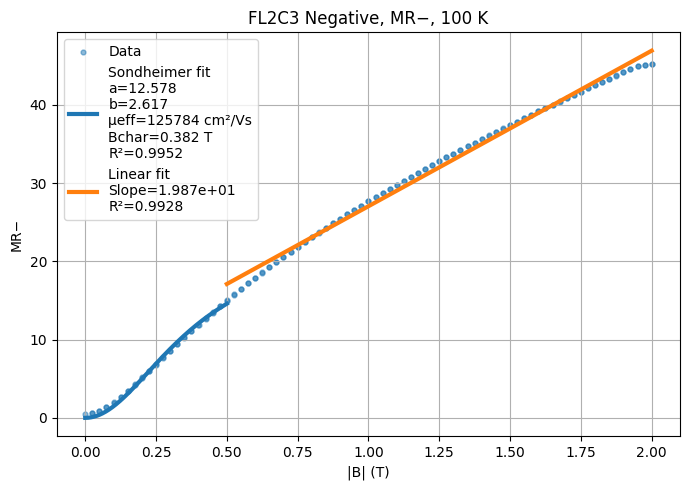

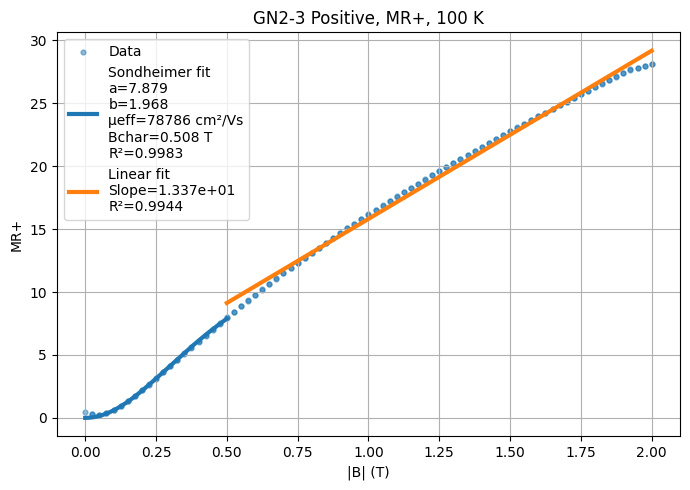

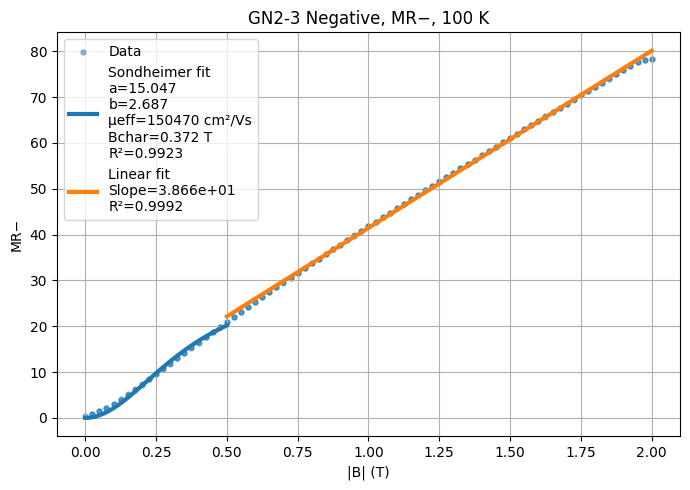


Analyzing Ch-3-FL2-C-3 and Ch-2-GN2-3 samples_MRat 200K_updated+-2Tesla_MR_with_derivatives.csv


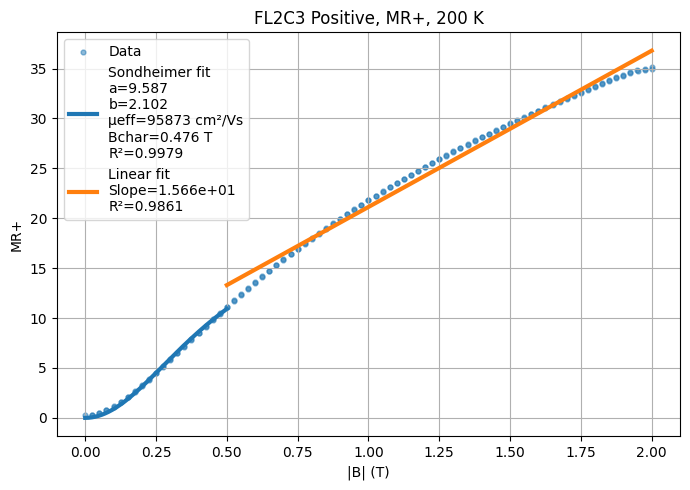

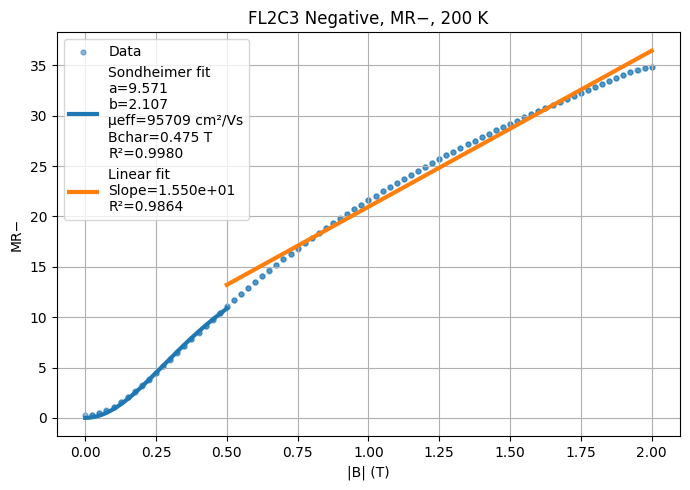

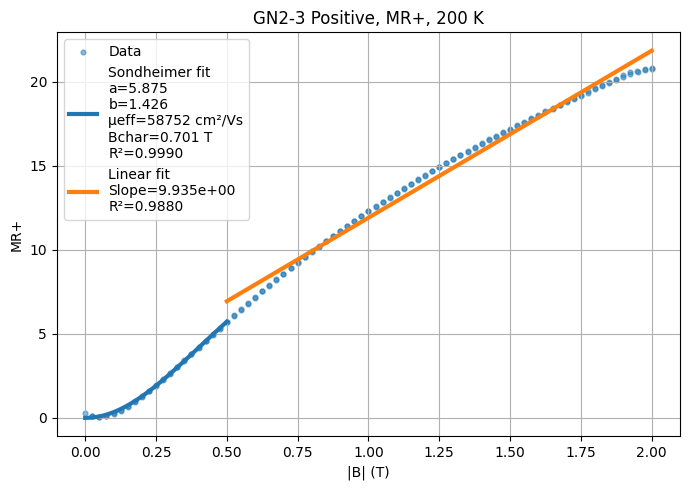

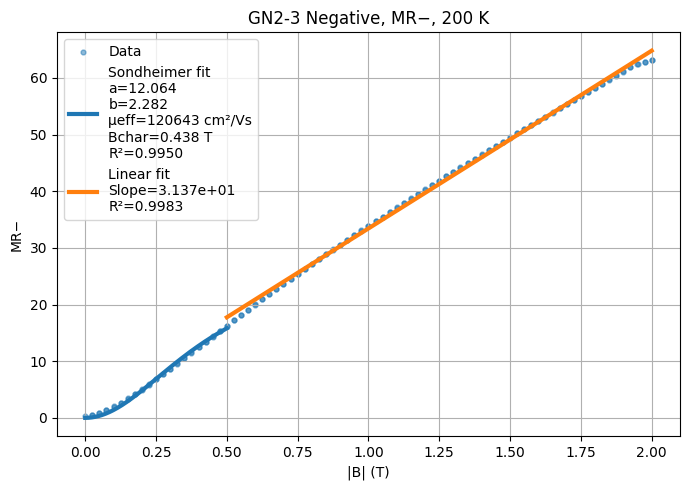


Analyzing Ch-3-FL2-C-3 and Ch-2-GN2-3 samples_MRat 20K_updated+-2Tesla_MR_with_derivatives.csv


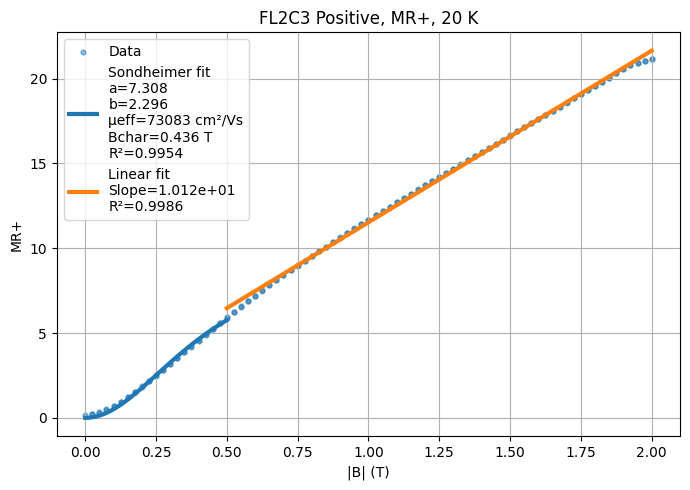

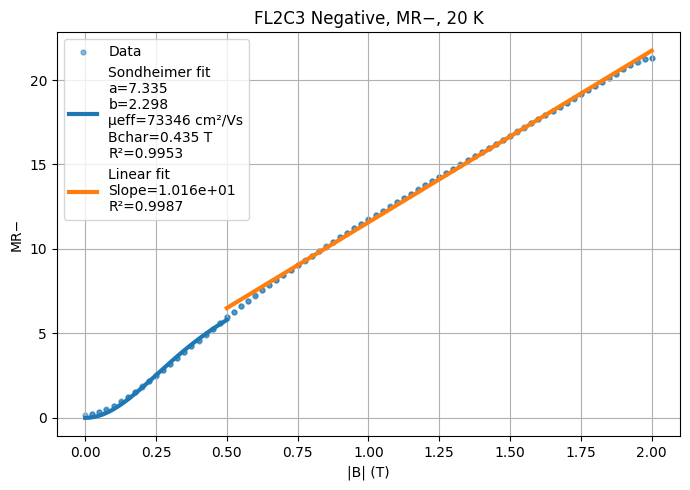

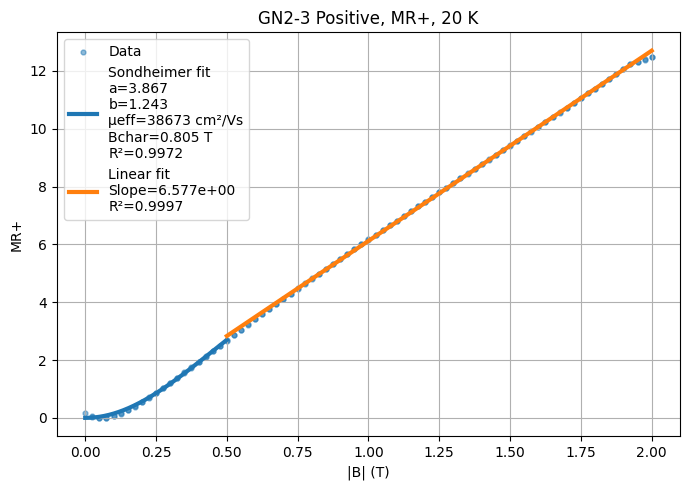

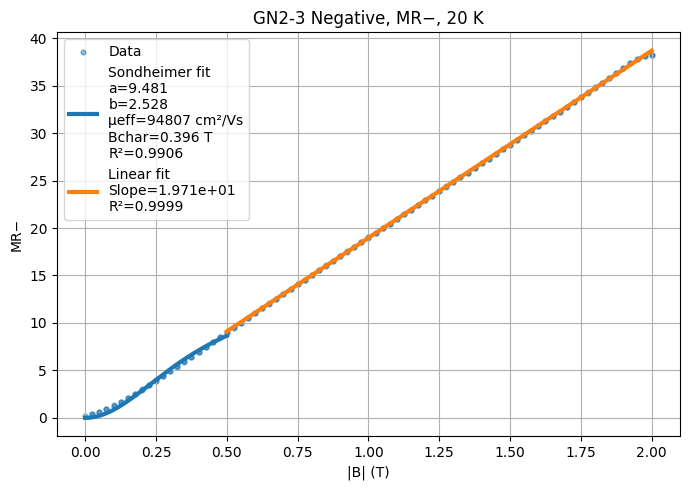


Analyzing Ch-3-FL2-C-3 and Ch-2-GN2-3 samples_MRat 250K_updated+-2Tesla_MR_with_derivatives.csv


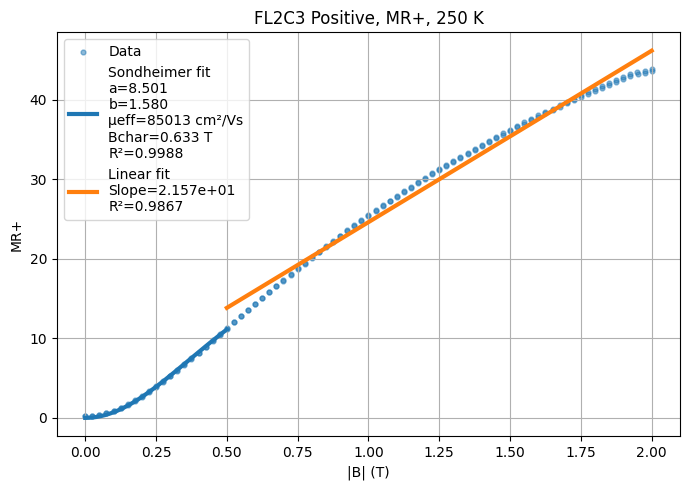

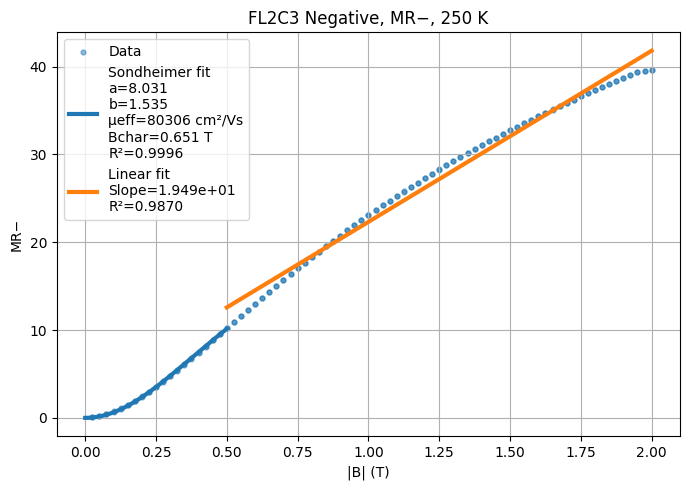

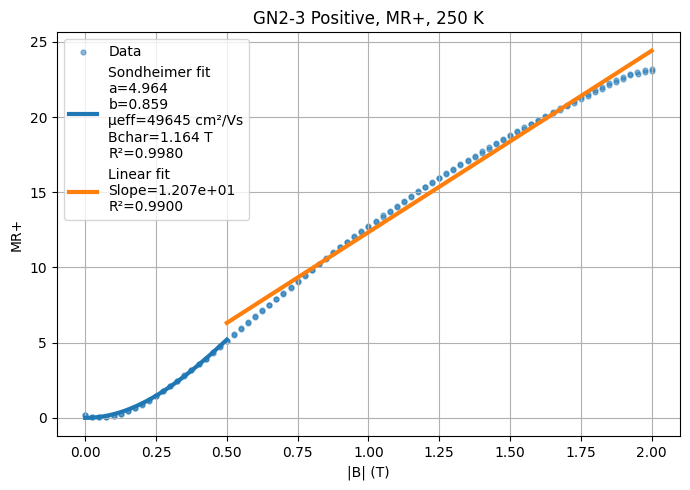

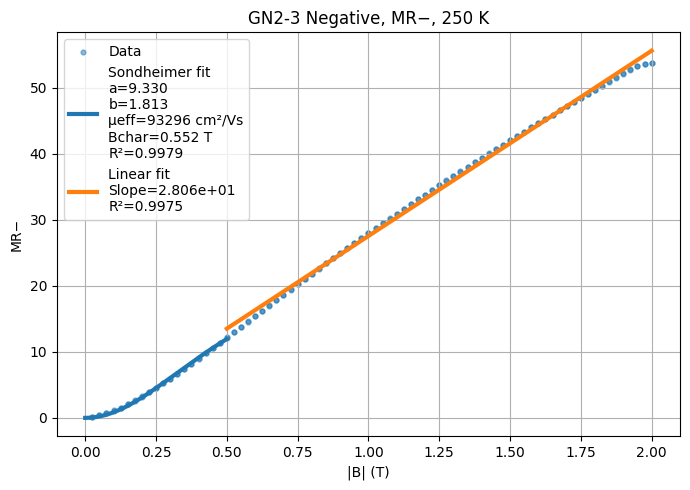


Analyzing Ch-3-FL2-C-3 and Ch-2-GN2-3 samples_MRat 300K_updated+-2Tesla_MR_with_derivatives.csv


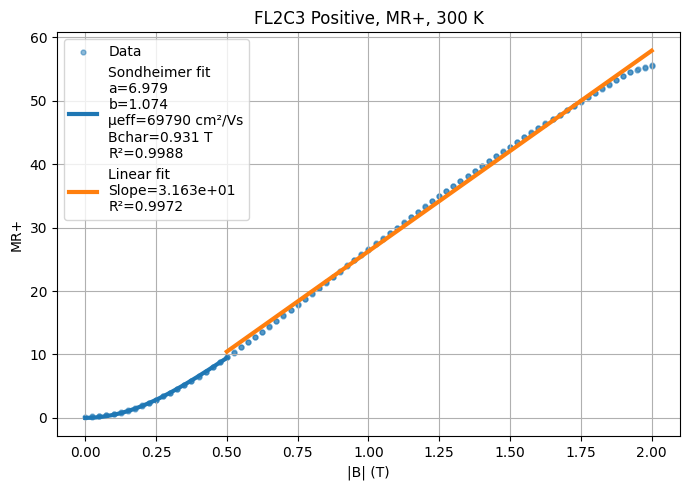

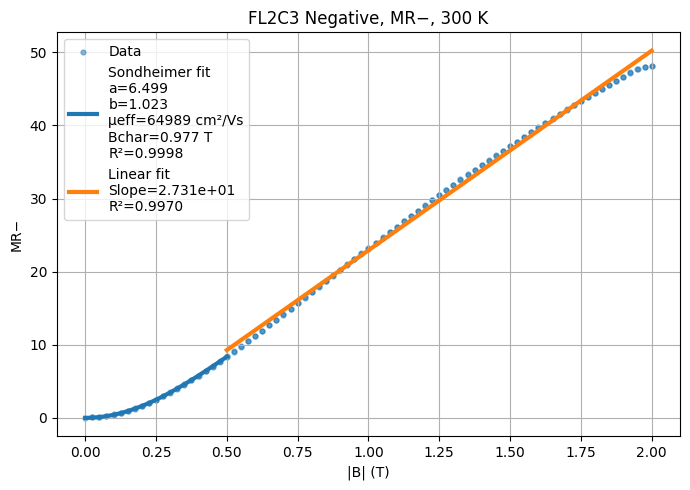

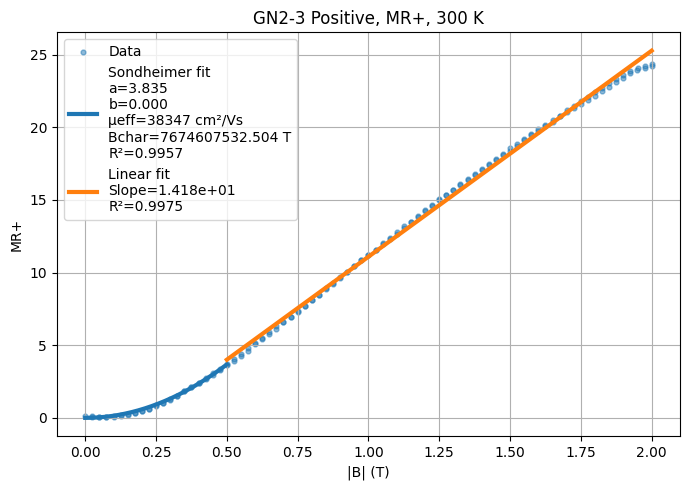

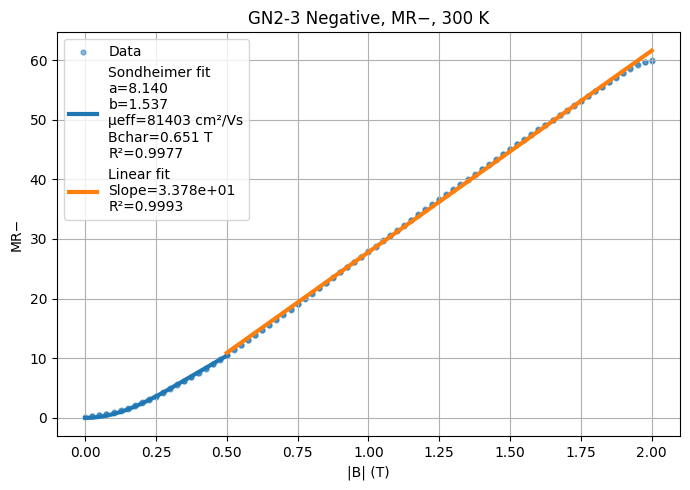


Analyzing Ch-3-FL2-C-3 and Ch-2-GN2-3 samples_MRat 50K_updated+-2Tesla_MR_with_derivatives.csv


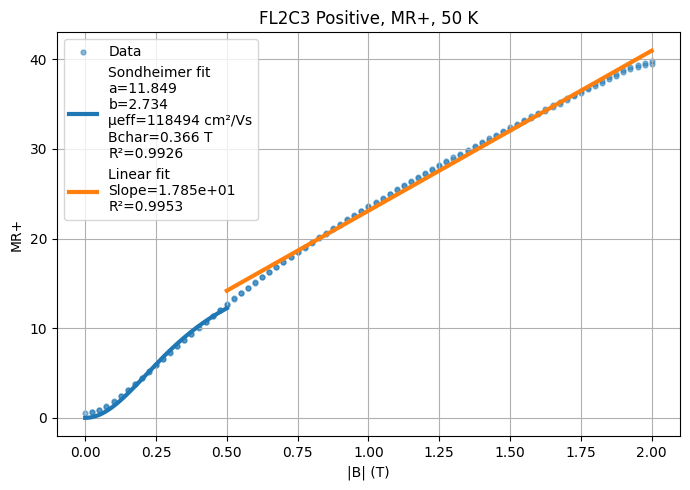

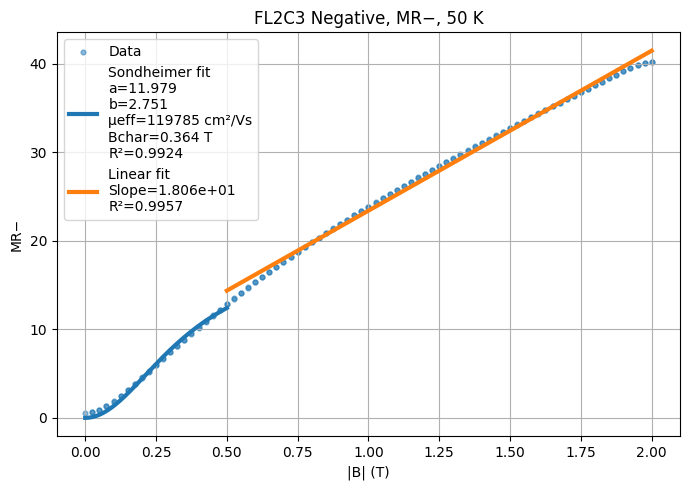

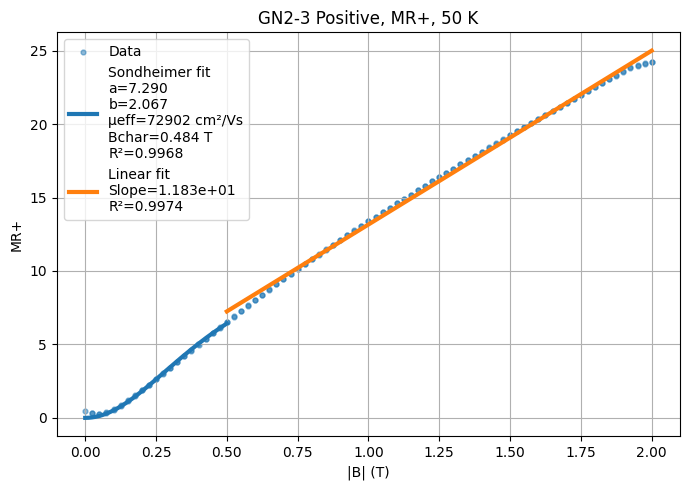

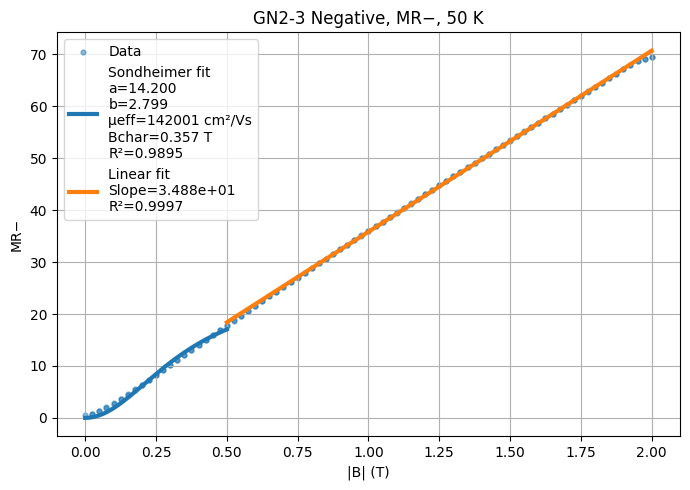

,Temperature_K,Sample,Branch,MR_definition,a_parameter,b_parameter,Mobility_like_cm2_Vs,Characteristic_Field_T,Sondheimer_R2,Linear_slope,Linear_intercept,Linear_R2
9,20,FL2C3,Negative,MR−,7.334585,2.298294e+00,73345.850231,4.351053e-01,0.995288,10.156785,1.422619,0.998702
8,20,FL2C3,Positive,MR+,7.308309,2.295757e+00,73083.091471,4.355862e-01,0.995395,10.115551,1.407749,0.998595
11,20,GN2-3,Negative,MR−,9.480655,2.528405e+00,94806.549558,3.955063e-01,0.990596,19.714532,-0.747371,0.999919
10,20,GN2-3,Positive,MR+,3.867324,1.242931e+00,38673.236315,8.045497e-01,0.997226,6.576861,-0.457699,0.999665
21,50,FL2C3,Negative,MR−,11.978521,2.750771e+00,119785.213583,3.635344e-01,0.992404,18.062721,5.333079,0.995731
20,50,FL2C3,Positive,MR+,11.849429,2.734043e+00,118494.294653,3.657587e-01,0.992646,17.850687,5.263479,0.995271
23,50,GN2-3,Negative,MR−,14.200051,2.798939e+00,142000.506034,3.572782e-01,0.989500,34.876072,0.970714,0.999697
22,50,GN2-3,Positive,MR+,7.290195,2.067320e+00,72901.950696,4.837180e-01,0.996805,11.831348,1.330923,0.997377
1,100,FL2C3,Negative,MR−,12.578425,2.617064e+00,125784.247105,3.821076e-01,0.995189,19.869079,7.166951,0.992800
0,100,FL2C3,Positive,MR+,12.395975,2.596140e+00,123959.748865,3.851872e-01,0.995324,19.477279,7.091425,0.992049


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [6]:
from scipy.optimize import curve_fit
import glob
import os
import zipfile
import re

# ============================================================
# FIT SETTINGS
# ============================================================

SONDHEIMER_MAX = 0.5
LINEAR_MIN = 0.5
LINEAR_MAX = 2.0

fit_summary = []

# ============================================================
# MODELS
# ============================================================

def sondheimer_ab_model(B, a, b):
    return (a * B)**2 / (1 + (b * B)**2)

def linear_model(B, m, c):
    return m * B + c

def calculate_r2(y, yfit):
    ss_res = np.sum((y - yfit)**2)
    ss_tot = np.sum((y - np.mean(y))**2)
    return np.nan if ss_tot == 0 else 1 - ss_res / ss_tot

def extract_temperature(filename):
    match = re.search(r'MRat\s*(\d+)K', filename)
    return int(match.group(1)) if match else None

# ============================================================
# FIT FUNCTION
# ============================================================

def analyze_branch_ab(B, MR, sample_name, branch_name, mr_label, T, base):

    B = np.asarray(B)
    MR = np.asarray(MR)

    valid = np.isfinite(B) & np.isfinite(MR)
    B = B[valid]
    MR = MR[valid]

    low_mask = (B >= 0) & (B <= SONDHEIMER_MAX)
    B_low = B[low_mask]
    MR_low = MR[low_mask]

    popt_ab, _ = curve_fit(
        sondheimer_ab_model,
        B_low,
        MR_low,
        p0=[1.0, 1.0],
        bounds=([0, 0], [np.inf, np.inf]),
        maxfev=20000
    )

    a_fit, b_fit = popt_ab
    MR_ab_fit = sondheimer_ab_model(B_low, a_fit, b_fit)
    r2_ab = calculate_r2(MR_low, MR_ab_fit)

    mu_eff_cm2_vs = a_fit * 1e4
    characteristic_field_T = 1 / b_fit if b_fit > 0 else np.nan

    lin_mask = (B >= LINEAR_MIN) & (B <= LINEAR_MAX)
    B_lin = B[lin_mask]
    MR_lin = MR[lin_mask]

    popt_lin, _ = curve_fit(linear_model, B_lin, MR_lin)
    m_fit, c_fit = popt_lin

    MR_lin_fit = linear_model(B_lin, m_fit, c_fit)
    r2_lin = calculate_r2(MR_lin, MR_lin_fit)

    plt.figure(figsize=(7,5))
    plt.scatter(B, MR, s=12, alpha=0.5, label='Data')

    B_ab_theory = np.linspace(0, SONDHEIMER_MAX, 300)
    plt.plot(
        B_ab_theory,
        sondheimer_ab_model(B_ab_theory, a_fit, b_fit),
        linewidth=3,
        label=(
            f'Sondheimer fit\n'
            f'a={a_fit:.3f}\n'
            f'b={b_fit:.3f}\n'
            f'μeff={mu_eff_cm2_vs:.0f} cm²/Vs\n'
            f'Bchar={characteristic_field_T:.3f} T\n'
            f'R²={r2_ab:.4f}'
        )
    )

    B_lin_theory = np.linspace(LINEAR_MIN, LINEAR_MAX, 300)
    plt.plot(
        B_lin_theory,
        linear_model(B_lin_theory, m_fit, c_fit),
        linewidth=3,
        label=(
            f'Linear fit\n'
            f'Slope={m_fit:.3e}\n'
            f'R²={r2_lin:.4f}'
        )
    )

    plt.xlabel('|B| (T)')
    plt.ylabel(mr_label)
    plt.title(f'{sample_name} {branch_name}, {mr_label}, {T} K')
    plt.grid(True)
    plt.legend()
    plt.tight_layout()

    plot_name = f'{base}_{sample_name}_{branch_name}_{mr_label}_sondheimer_linear_fit.png'
    plt.savefig(os.path.join(outdir, plot_name), dpi=300)
    plt.show()

    fit_summary.append({
        'Temperature_K': T,
        'Sample': sample_name,
        'Branch': branch_name,
        'MR_definition': mr_label,
        'a_parameter': a_fit,
        'b_parameter': b_fit,
        'Mobility_like_cm2_Vs': mu_eff_cm2_vs,
        'Characteristic_Field_T': characteristic_field_T,
        'Sondheimer_R2': r2_ab,
        'Linear_slope': m_fit,
        'Linear_intercept': c_fit,
        'Linear_R2': r2_lin
    })

# ============================================================
# LOOP OVER ALL PROCESSED TEMPERATURE FILES
# ============================================================

processed_files = glob.glob(os.path.join(outdir, "*_MR_with_derivatives.csv"))

if len(processed_files) == 0:
    processed_files = glob.glob(os.path.join(outdir, "*_MR_derivatives.csv"))

for file in sorted(processed_files):

    fname = os.path.basename(file)
    base = os.path.splitext(fname)[0]
    T = extract_temperature(fname)

    print("\n" + "="*90)
    print(f"Analyzing {fname}")
    print("="*90)

    df = pd.read_csv(file)

    for sample in ['FL2C3', 'GN2-3']:

        # Positive field branch uses MR+
        mask_pos = df['Field_T'] > 0
        B_pos = df.loc[mask_pos, 'Field_T'].values
        MR_pos = df.loc[mask_pos, f'MR_{sample}_plus_smooth'].values

        analyze_branch_ab(
            B_pos,
            MR_pos,
            sample,
            'Positive',
            'MR+',
            T,
            base
        )

        # Negative field branch uses MR−
        mask_neg = df['Field_T'] < 0
        B_neg = np.abs(df.loc[mask_neg, 'Field_T'].values)
        MR_neg = df.loc[mask_neg, f'MR_{sample}_minus_smooth'].values

        analyze_branch_ab(
            B_neg,
            MR_neg,
            sample,
            'Negative',
            'MR−',
            T,
            base
        )

# ============================================================
# EXPORT SUMMARY
# ============================================================

fit_summary_df = pd.DataFrame(fit_summary)
fit_summary_df = fit_summary_df.sort_values(
    ['Temperature_K', 'Sample', 'Branch']
)

display(fit_summary_df)

fit_summary_df.to_csv(
    os.path.join(outdir, "MR_plus_minus_sondheimer_linear_fit_summary_ALL_T.csv"),
    index=False
)

zip_out = "MR_plus_minus_sondheimer_linear_fits_ALL_T.zip"

with zipfile.ZipFile(zip_out, 'w') as z:
    for root, dirs, filenames in os.walk(outdir):
        for f in filenames:
            fullpath = os.path.join(root, f)
            z.write(fullpath, arcname=os.path.relpath(fullpath, outdir))

files.download(zip_out)